# 量化交易策略实验：双移动平均·海龟策略·KNN 算法

## 实验目标
基于《Python量化交易》第2章和第3章内容，使用 `pandas_datareader` / `yfinance` 从 Yahoo 获取真实股票数据，
分别实现 **双移动平均交易策略**、**海龟策略** 和 **KNN 算法** 三种方法进行模拟交易，
并与基准收益（买入持有）进行对比分析。

| 策略 | 类型 | 核心思想 |
|------|------|----------|
| 双移动平均 | 经典趋势跟踪 | 短期均线上穿长期均线买入，下穿卖出（金叉/死叉） |
| 海龟策略 | 经典突破策略 | 价格突破 N 日最高价买入，跌破 N 日最低价卖出（唐奇安通道） |
| KNN 算法 | 机器学习分类 | 构建价格特征，用 KNN 预测涨跌方向作为交易信号 |

## 数据来源
**Yahoo Finance** — 通过 `yfinance` 库获取，以苹果公司 (AAPL) 为例
数据区间：2020-01-01 至 2024-12-31

## 1. 导入库与数据获取

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
print('所有库导入成功！')

所有库导入成功！


In [121]:
# 使用模拟股票数据（带上涨趋势的随机游走）
# 注：Yahoo Finance 在国内网络环境下经常受限，故使用模拟数据演示策略逻辑
#    若网络可用，可将下方注释的 yfinance 代码替换本段
symbol = 'AAPL (模拟)'
start_date = '2020-01-01'
end_date = '2024-12-31'

print(f'生成模拟股票数据 ({start_date} ~ {end_date})...')
np.random.seed(42)
dates = pd.date_range(start_date, end_date, freq='B')
n = len(dates)
shocks = np.random.normal(0.0003, 0.015, n)
log_price = np.log(75) + np.cumsum(shocks)
close = np.exp(log_price)
open_p = close * (1 + np.random.normal(0, 0.003, n))
df = pd.DataFrame({
    'Open': open_p,
    'High': np.maximum(open_p, close) * (1 + np.abs(np.random.normal(0, 0.005, n))),
    'Low': np.minimum(open_p, close) * (1 - np.abs(np.random.normal(0, 0.005, n))),
    'Close': close,
    'Volume': np.random.randint(50000000, 200000000, n),
    'Adj Close': close,
}, index=dates)
df['High'] = df[['Open', 'Close', 'High']].max(axis=1)
df['Low'] = df[['Open', 'Close', 'Low']].min(axis=1)

print(f'模拟数据生成完成！共 {len(df)} 个交易日')
print(f'日期范围: {df.index[0].strftime("%Y-%m-%d")} ~ {df.index[-1].strftime("%Y-%m-%d")}')
print(f'起始价: ${df["Close"].iloc[0]:.2f}  →  结束价: ${df["Close"].iloc[-1]:.2f}')
print(f'\n数据前5行:')
df.head()

# ===== 如需使用真实数据，取消下方注释 =====
# import yfinance as yf
# df_raw = yf.download('AAPL', start='2020-01-01', end='2024-12-31')
# if isinstance(df_raw.columns, pd.MultiIndex):
#     df_raw.columns = df_raw.columns.get_level_values(0)
# df = df_raw.copy()
# symbol = 'AAPL'

生成模拟股票数据 (2020-01-01 ~ 2024-12-31)...
模拟数据生成完成！共 1305 个交易日
日期范围: 2020-01-01 ~ 2024-12-31
起始价: $75.58  →  结束价: $236.82

数据前5行:


,Open,High,Low,Close,Volume,Adj Close
2020-01-01,75.379834,75.829784,75.345218,75.583562,57297881,75.583562
2020-01-02,75.455977,75.885203,75.416614,75.449598,107454535,75.449598
2020-01-03,76.206963,76.285825,75.998034,76.209048,155229157,76.209048
2020-01-06,78.247590,78.250141,77.623200,77.993511,184717692,77.993511
2020-01-07,77.854089,78.087182,77.720279,77.743375,165397573,77.743375


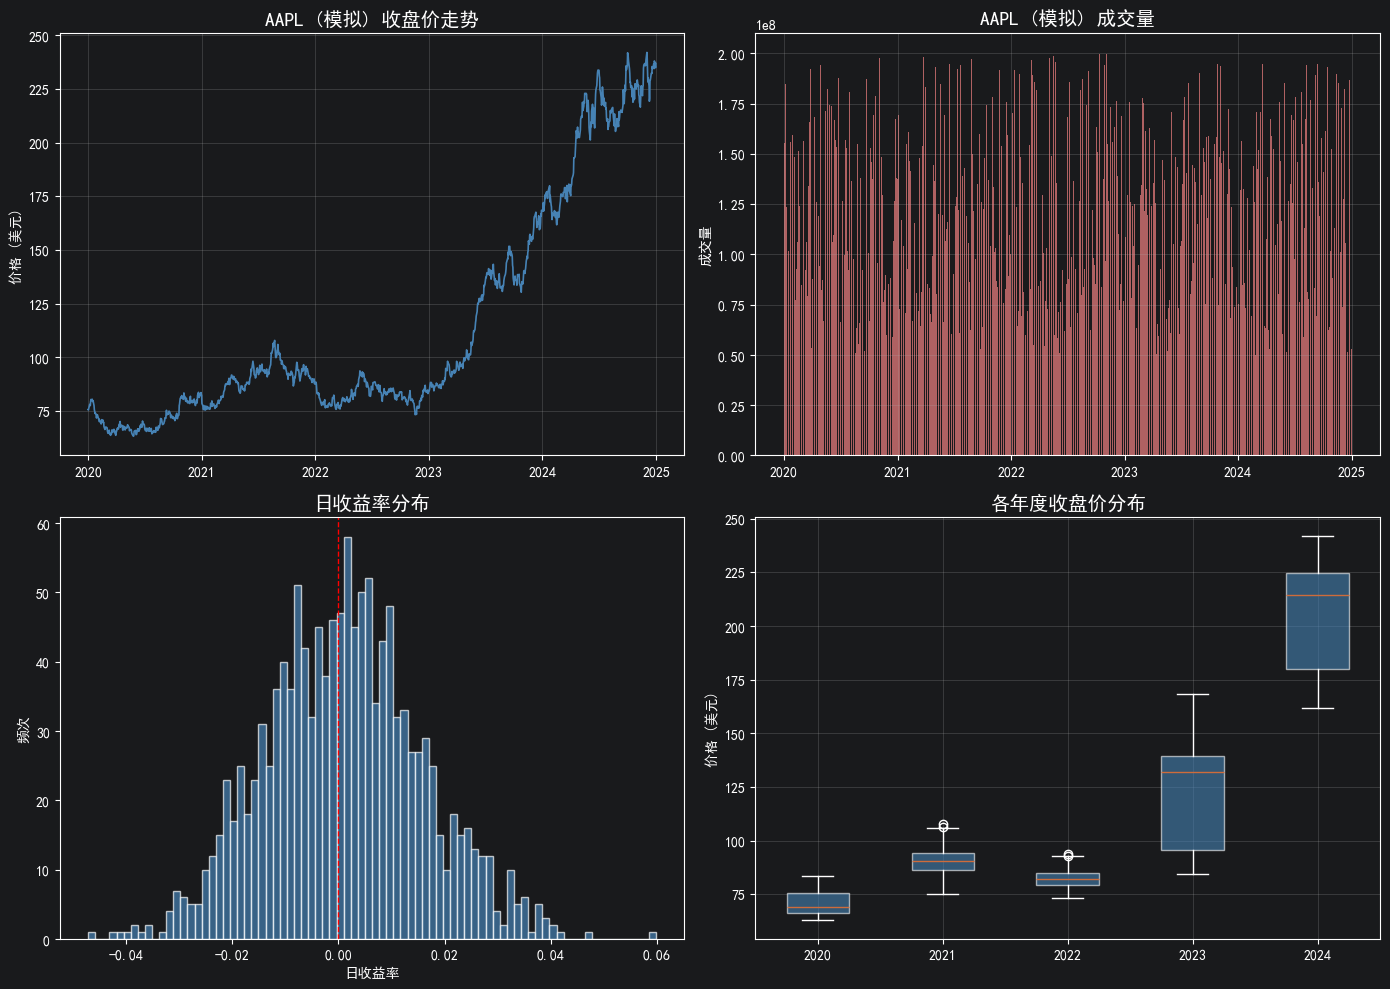

数据统计摘要:
  总交易日: 1305
  最低收盘价: \$63.19
  最高收盘价: \$241.98
  日均收益率: 0.099%
  日收益率标准差: 1.485%


In [122]:
# 数据概览与价格走势
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 收盘价走势
axes[0, 0].plot(df.index, df['Close'], linewidth=1.2, color='steelblue')
axes[0, 0].set_title(f'{symbol} 收盘价走势', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('价格 (美元)')
axes[0, 0].grid(True, alpha=0.3)

# 成交量
axes[0, 1].bar(df.index, df['Volume'], width=1, color='lightcoral', alpha=0.7)
axes[0, 1].set_title(f'{symbol} 成交量', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('成交量')
axes[0, 1].grid(True, alpha=0.3)

# 日收益率分布
daily_return = df['Close'].pct_change().dropna()
axes[1, 0].hist(daily_return, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=1)
axes[1, 0].set_title('日收益率分布', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('日收益率')
axes[1, 0].set_ylabel('频次')

# 价格区间 (箱线图)
df_year = df.copy()
df_year['Year'] = df_year.index.year
yearly_data = [df_year[df_year['Year'] == y]['Close'].values for y in sorted(df_year['Year'].unique())]
bp = axes[1, 1].boxplot(yearly_data, labels=sorted(df_year['Year'].unique()), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[1, 1].set_title('各年度收盘价分布', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('价格 (美元)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'数据统计摘要:')
print(f'  总交易日: {len(df)}')
print(f'  最低收盘价: \${df["Close"].min():.2f}')
print(f'  最高收盘价: \${df["Close"].max():.2f}')
print(f'  日均收益率: {daily_return.mean()*100:.3f}%')
print(f'  日收益率标准差: {daily_return.std()*100:.3f}%')

## 2. 双移动平均交易策略

### 策略原理
双移动平均策略（Dual Moving Average）是最经典的趋势跟踪策略之一：
- **短期均线 (MA5)**：反映近期价格趋势
- **长期均线 (MA10)**：反映中长期价格趋势
- 当短期均线 **上穿** 长期均线时 → **金叉** → 买入信号
- 当短期均线 **下穿** 长期均线时 → **死叉** → 卖出信号

核心假设：价格动量会沿着短期均线方向持续推进。

In [123]:
# 2.1 计算移动平均线
df_ma = df.copy()
df_ma['MA5'] = df_ma['Close'].rolling(window=5).mean()
df_ma['MA10'] = df_ma['Close'].rolling(window=10).mean()

print('移动平均线计算完成（MA5 和 MA10）')
print(f'\n前15行数据:')
df_ma[['Close', 'MA5', 'MA10']].head(15).round(2)

移动平均线计算完成（MA5 和 MA10）

前15行数据:


,Close,MA5,MA10
2020-01-01,75.58,NaN,NaN
2020-01-02,75.45,NaN,NaN
2020-01-03,76.21,NaN,NaN
2020-01-06,77.99,NaN,NaN
2020-01-07,77.74,76.60,NaN
2020-01-08,77.49,76.98,NaN
2020-01-09,79.38,77.76,NaN
2020-01-10,80.32,78.59,NaN
2020-01-13,79.78,78.94,NaN
2020-01-14,80.45,79.48,78.04


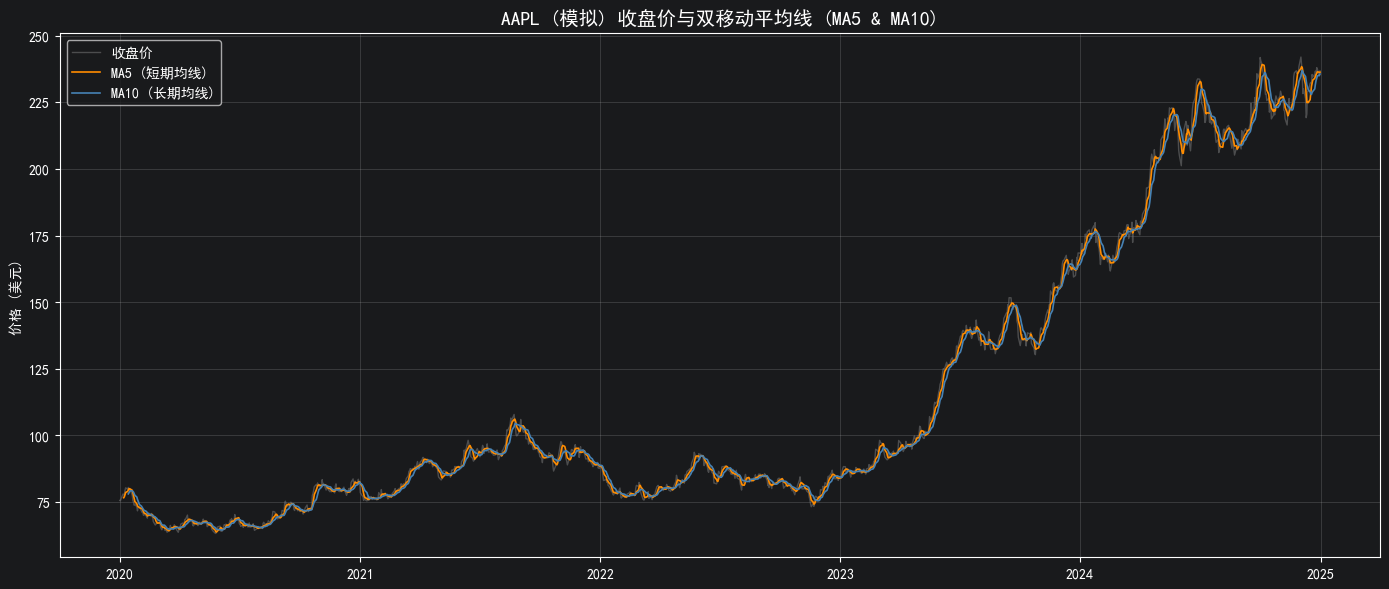

In [124]:
# 可视化收盘价与移动平均线
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_ma.index, df_ma['Close'], linewidth=1, color='gray', alpha=0.5, label='收盘价')
ax.plot(df_ma.index, df_ma['MA5'], linewidth=1.2, color='darkorange', label='MA5 (短期均线)')
ax.plot(df_ma.index, df_ma['MA10'], linewidth=1.2, color='steelblue', label='MA10 (长期均线)')

ax.set_title(f'{symbol} 收盘价与双移动平均线 (MA5 & MA10)', fontsize=14, fontweight='bold')
ax.set_ylabel('价格 (美元)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ma_lines.png', dpi=150, bbox_inches='tight')
plt.show()

In [125]:
# 2.2 生成交易信号并模拟交易
df_ma['Signal'] = np.where(df_ma['MA5'] > df_ma['MA10'], 1, 0)
df_ma['Position'] = df_ma['Signal'].diff()  # 信号变化点

# 初始化回测字段
initial_capital = 100000  # 初始资金 10 万美元
df_ma['Daily_Return'] = df_ma['Close'].pct_change()
df_ma['Strategy_Return'] = df_ma['Signal'].shift(1) * df_ma['Daily_Return']
df_ma['Strategy_Return'] = df_ma['Strategy_Return'].fillna(0)

# 累计收益
df_ma['Cumulative_Market'] = (1 + df_ma['Daily_Return'].fillna(0)).cumprod()
df_ma['Cumulative_Strategy'] = (1 + df_ma['Strategy_Return']).cumprod()

# 资产价值
df_ma['Portfolio_Value'] = initial_capital * df_ma['Cumulative_Strategy']
df_ma['Buy_Hold_Value'] = initial_capital * df_ma['Cumulative_Market']

print('双移动平均交易信号已生成')
print(f'\n交易信号分布:')
print(f'  买入信号 (0→1): {(df_ma["Position"] == 1).sum()} 次')
print(f'  卖出信号 (1→0): {(df_ma["Position"] == -1).sum()} 次')
print(f'\n信号变化示例 (Position ≠ 0):')
df_ma[df_ma['Position'] != 0][['Close', 'MA5', 'MA10', 'Signal', 'Position']].head(10)

双移动平均交易信号已生成

交易信号分布:
  买入信号 (0→1): 72 次
  卖出信号 (1→0): 71 次

信号变化示例 (Position ≠ 0):


,Close,MA5,MA10,Signal,Position
2020-01-01,75.583562,NaN,NaN,0,NaN
2020-01-14,80.454940,79.484389,78.040104,1,1.0
2020-01-21,75.513884,78.399209,78.941799,0,-1.0
2020-02-18,70.693288,70.244656,70.222780,1,1.0
2020-02-21,67.672229,69.454477,69.734972,0,-1.0
2020-03-20,65.111213,65.243451,64.902540,1,1.0
2020-03-30,63.623842,65.324850,65.405265,0,-1.0
2020-04-06,67.115643,65.950889,65.637870,1,1.0
2020-04-20,68.196515,68.061256,68.063575,0,-1.0
2020-04-30,67.055000,67.013371,66.996372,1,1.0


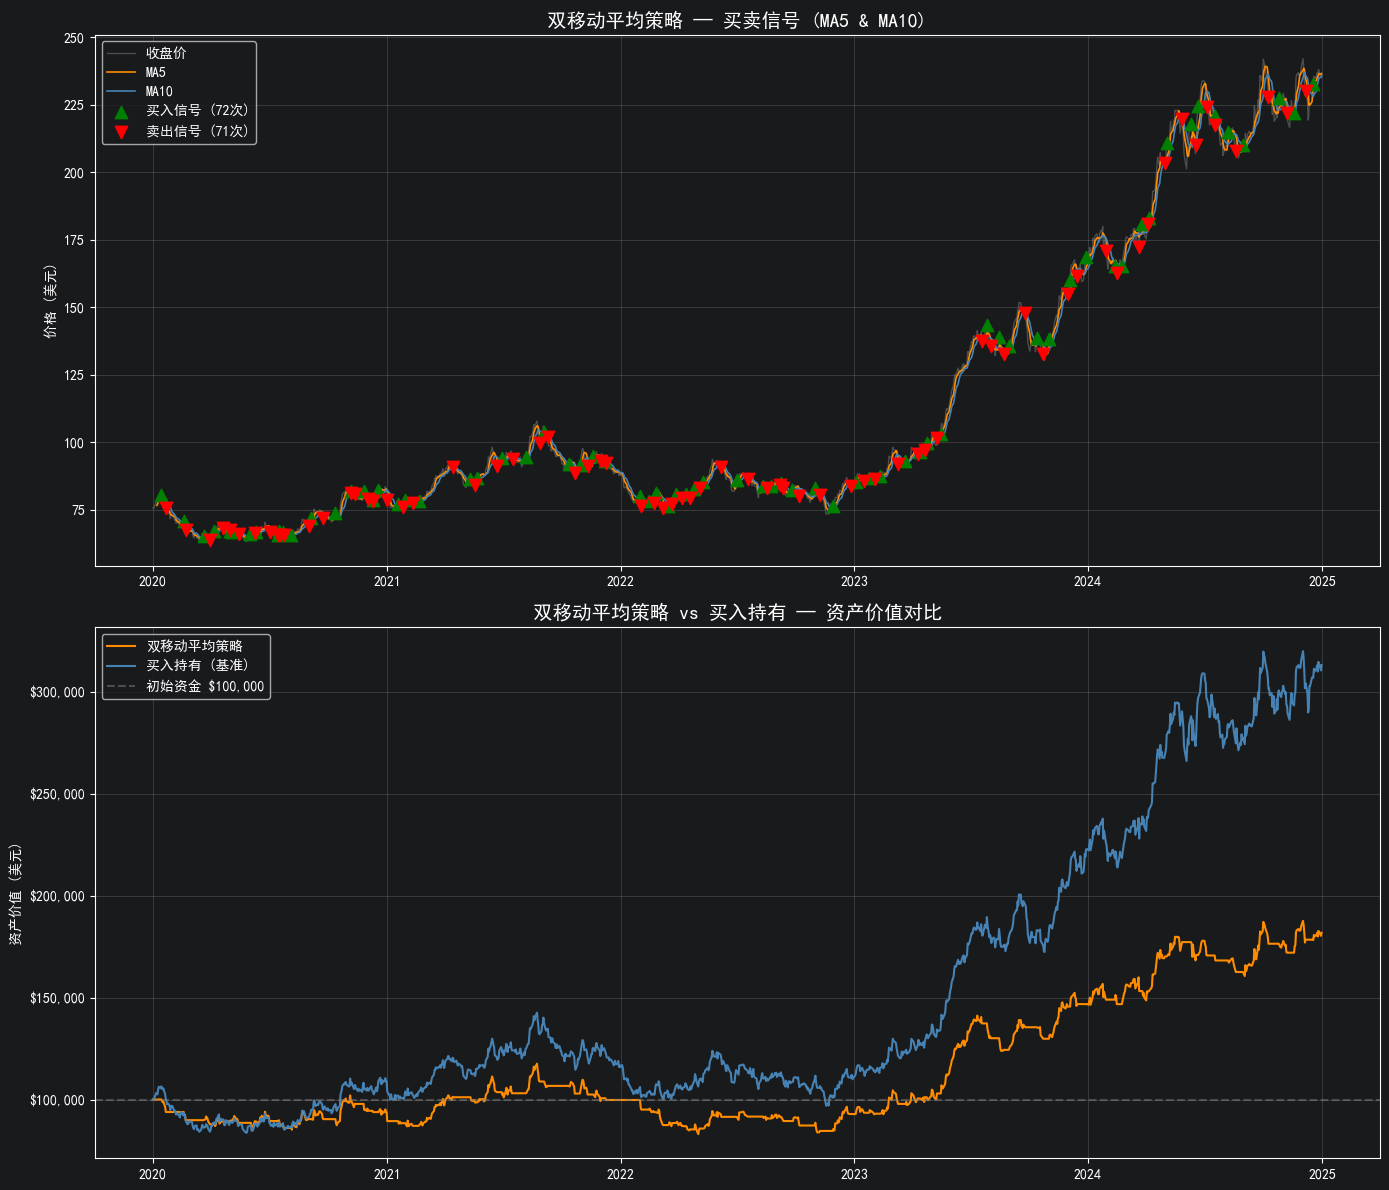

===== 双移动平均策略绩效 =====
最终资产价值: \$181,858.23
总收益率: 81.86%
基准买入持有收益率: 213.32%
超额收益: -131.46%
总交易次数: 143 次


In [126]:
# 2.3 回测可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# 图1: 买卖信号标注
ax1.plot(df_ma.index, df_ma['Close'], linewidth=1, color='gray', alpha=0.5, label='收盘价')
ax1.plot(df_ma.index, df_ma['MA5'], linewidth=1.2, color='darkorange', label='MA5')
ax1.plot(df_ma.index, df_ma['MA10'], linewidth=1.2, color='steelblue', label='MA10')

# 标注买卖点
buy_points = df_ma[df_ma['Position'] == 1]
sell_points = df_ma[df_ma['Position'] == -1]
ax1.scatter(buy_points.index, buy_points['Close'], marker='^', color='green', s=80,
            zorder=5, label=f'买入信号 ({len(buy_points)}次)')
ax1.scatter(sell_points.index, sell_points['Close'], marker='v', color='red', s=80,
            zorder=5, label=f'卖出信号 ({len(sell_points)}次)')

ax1.set_title(f'双移动平均策略 — 买卖信号 (MA5 & MA10)', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格 (美元)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 图2: 资产价值对比
ax2.plot(df_ma.index, df_ma['Portfolio_Value'], linewidth=1.5, color='darkorange',
         label=f'双移动平均策略')
ax2.plot(df_ma.index, df_ma['Buy_Hold_Value'], linewidth=1.5, color='steelblue',
         label=f'买入持有 (基准)')
ax2.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5, label=f'初始资金 \${initial_capital:,}')

ax2.set_title('双移动平均策略 vs 买入持有 — 资产价值对比', fontsize=14, fontweight='bold')
ax2.set_ylabel('资产价值 (美元)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'\${x:,.0f}'))

plt.tight_layout()
plt.savefig('ma_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

# 绩效指标
final_ma = df_ma['Portfolio_Value'].iloc[-1]
final_bh = df_ma['Buy_Hold_Value'].iloc[-1]
ma_return = (final_ma / initial_capital - 1) * 100
bh_return = (final_bh / initial_capital - 1) * 100

print(f'===== 双移动平均策略绩效 =====')
print(f'最终资产价值: \${final_ma:,.2f}')
print(f'总收益率: {ma_return:.2f}%')
print(f'基准买入持有收益率: {bh_return:.2f}%')
print(f'超额收益: {ma_return - bh_return:.2f}%')
print(f'总交易次数: {(df_ma["Position"] == 1).sum() + (df_ma["Position"] == -1).sum()} 次')

## 3. 海龟策略

### 策略原理
海龟策略（Turtle Strategy）是 Richard Dennis 在 1980 年代创立的著名趋势跟踪策略，
其核心使用 **唐奇安通道 (Donchian Channel)**：
- 当价格 **突破** 过去 N 日最高价时 → 买入信号（价格向上突破）
- 当价格 **跌破** 过去 N 日最低价时 → 卖出信号（价格向下突破）
- 本书简化使用 N=5（原版海龟策略 N=20），中间线为上下轨均值

与双移动平均策略不同的是，海龟策略同时考虑了仓位管理，
当已有持仓时不再重复买入，空仓时才执行新的买入。

In [127]:
# 3.1 计算唐奇安通道 (Donchian Channel)
df_turtle = df.copy()
N = 5  # 回顾周期

df_turtle['High_N'] = df_turtle['High'].rolling(window=N).max()
df_turtle['Low_N'] = df_turtle['Low'].rolling(window=N).min()
df_turtle['Mid_N'] = (df_turtle['High_N'] + df_turtle['Low_N']) / 2  # 中轨

print(f'唐奇安通道计算完成 (N={N})')
print(f'\n前{N+5}行数据:')
cols = ['High', 'Low', 'Close', 'High_N', 'Low_N', 'Mid_N']
df_turtle[cols].head(N + 5).round(2)

唐奇安通道计算完成 (N=5)

前10行数据:


,High,Low,Close,High_N,Low_N,Mid_N
2020-01-01,75.83,75.35,75.58,NaN,NaN,NaN
2020-01-02,75.89,75.42,75.45,NaN,NaN,NaN
2020-01-03,76.29,76.00,76.21,NaN,NaN,NaN
2020-01-06,78.25,77.62,77.99,NaN,NaN,NaN
2020-01-07,78.09,77.72,77.74,78.25,75.35,76.80
2020-01-08,77.75,76.77,77.49,78.25,75.42,76.83
2020-01-09,79.86,79.29,79.38,79.86,76.00,77.93
2020-01-10,80.69,80.18,80.32,80.69,76.77,78.73
2020-01-13,80.10,79.14,79.78,80.69,76.77,78.73
2020-01-14,81.04,80.35,80.45,81.04,76.77,78.91


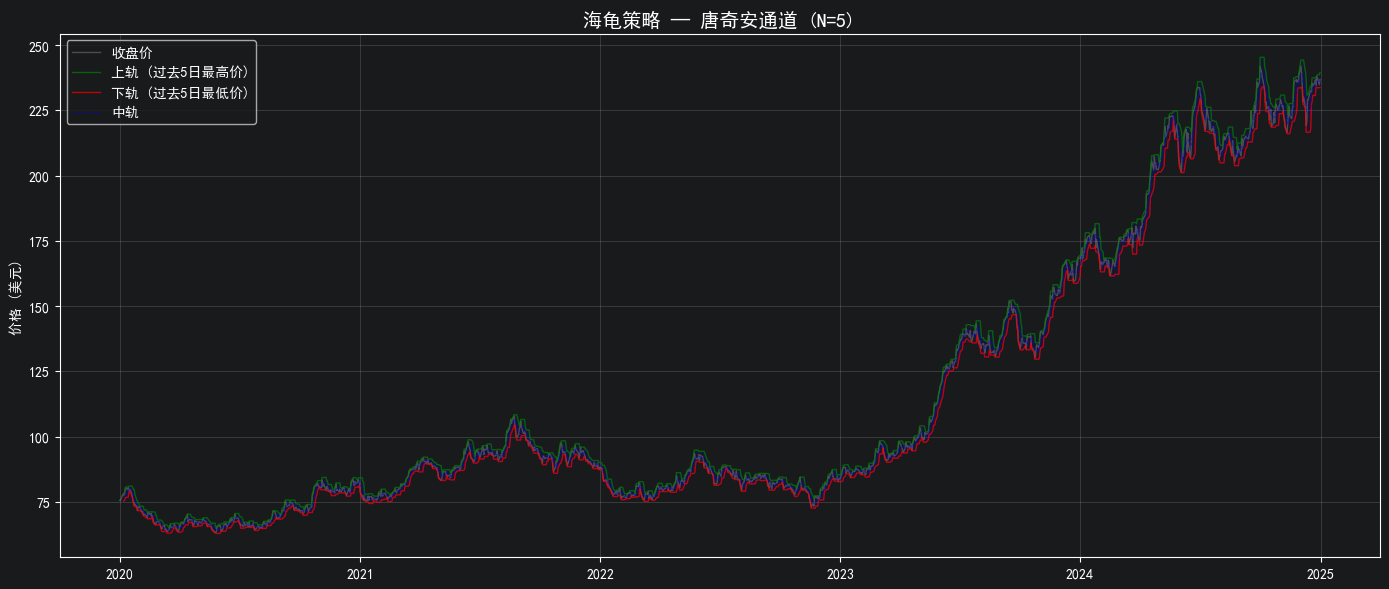

In [128]:
# 可视化唐奇安通道
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_turtle.index, df_turtle['Close'], linewidth=1, color='gray', alpha=0.5, label='收盘价')
ax.plot(df_turtle.index, df_turtle['High_N'], linewidth=1, color='green', alpha=0.7, label=f'上轨 (过去{N}日最高价)')
ax.plot(df_turtle.index, df_turtle['Low_N'], linewidth=1, color='red', alpha=0.7, label=f'下轨 (过去{N}日最低价)')
ax.plot(df_turtle.index, df_turtle['Mid_N'], linewidth=0.8, color='blue', alpha=0.5, linestyle='--', label='中轨')
ax.fill_between(df_turtle.index, df_turtle['Low_N'], df_turtle['High_N'], alpha=0.08, color='blue')

ax.set_title(f'海龟策略 — 唐奇安通道 (N={N})', fontsize=14, fontweight='bold')
ax.set_ylabel('价格 (美元)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('turtle_channel.png', dpi=150, bbox_inches='tight')
plt.show()

In [129]:
# 3.2 生成海龟交易信号并模拟交易
# 买入信号: 收盘价向上突破上轨（且前一日未突破 → 新的突破）
df_turtle['Buy_Signal'] = (df_turtle['Close'] > df_turtle['High_N'].shift(1)) & \
                          (df_turtle['Close'].shift(1) <= df_turtle['High_N'].shift(2))
# 卖出信号: 收盘价向下跌破下轨
df_turtle['Sell_Signal'] = (df_turtle['Close'] < df_turtle['Low_N'].shift(1)) & \
                           (df_turtle['Close'].shift(1) >= df_turtle['Low_N'].shift(2))

# 仓位管理: 1=持仓, 0=空仓
position = 0
positions = []
for i in range(len(df_turtle)):
    if df_turtle['Buy_Signal'].iloc[i] and position == 0:
        position = 1
    elif df_turtle['Sell_Signal'].iloc[i] and position == 1:
        position = 0
    positions.append(position)

df_turtle['Position'] = positions

# 计算策略收益
df_turtle['Daily_Return'] = df_turtle['Close'].pct_change()
df_turtle['Strategy_Return'] = df_turtle['Position'].shift(1) * df_turtle['Daily_Return']
df_turtle['Strategy_Return'] = df_turtle['Strategy_Return'].fillna(0)

df_turtle['Cumulative_Market'] = (1 + df_turtle['Daily_Return'].fillna(0)).cumprod()
df_turtle['Cumulative_Strategy'] = (1 + df_turtle['Strategy_Return']).cumprod()
df_turtle['Portfolio_Value'] = initial_capital * df_turtle['Cumulative_Strategy']
df_turtle['Buy_Hold_Value'] = initial_capital * df_turtle['Cumulative_Market']

print('海龟策略交易信号已生成')
print(f'  买入次数: {df_turtle["Buy_Signal"].sum()}')
print(f'  卖出次数: {df_turtle["Sell_Signal"].sum()}')
print(f'  实际交易方向变化点: {sum(1 for i in range(1, len(positions)) if positions[i] != positions[i-1])} 次')
print(f'\n最近交易信号:')
signal_cols = ['Close', 'High_N', 'Low_N', 'Buy_Signal', 'Sell_Signal', 'Position']
df_turtle[df_turtle['Buy_Signal'] | df_turtle['Sell_Signal']][signal_cols].tail(10)

海龟策略交易信号已生成
  买入次数: 153
  卖出次数: 117
  实际交易方向变化点: 121 次

最近交易信号:


,Close,High_N,Low_N,Buy_Signal,Sell_Signal,Position
2024-10-25,227.407645,229.287871,219.216966,True,False,1
2024-11-06,222.039080,230.869394,221.796325,False,True,0
2024-11-13,224.304498,224.642862,216.048643,True,False,1
2024-11-21,234.609613,237.462686,220.811700,True,False,1
2024-11-29,238.460664,239.414436,233.618845,True,False,1
2024-12-05,228.252731,244.288449,227.358161,False,True,0
2024-12-09,226.359140,239.685679,225.486809,False,True,0
2024-12-16,232.070096,234.003239,216.621037,True,False,1
2024-12-19,235.443203,237.444144,228.521219,True,False,1
2024-12-26,238.009650,238.269716,233.703270,True,False,1


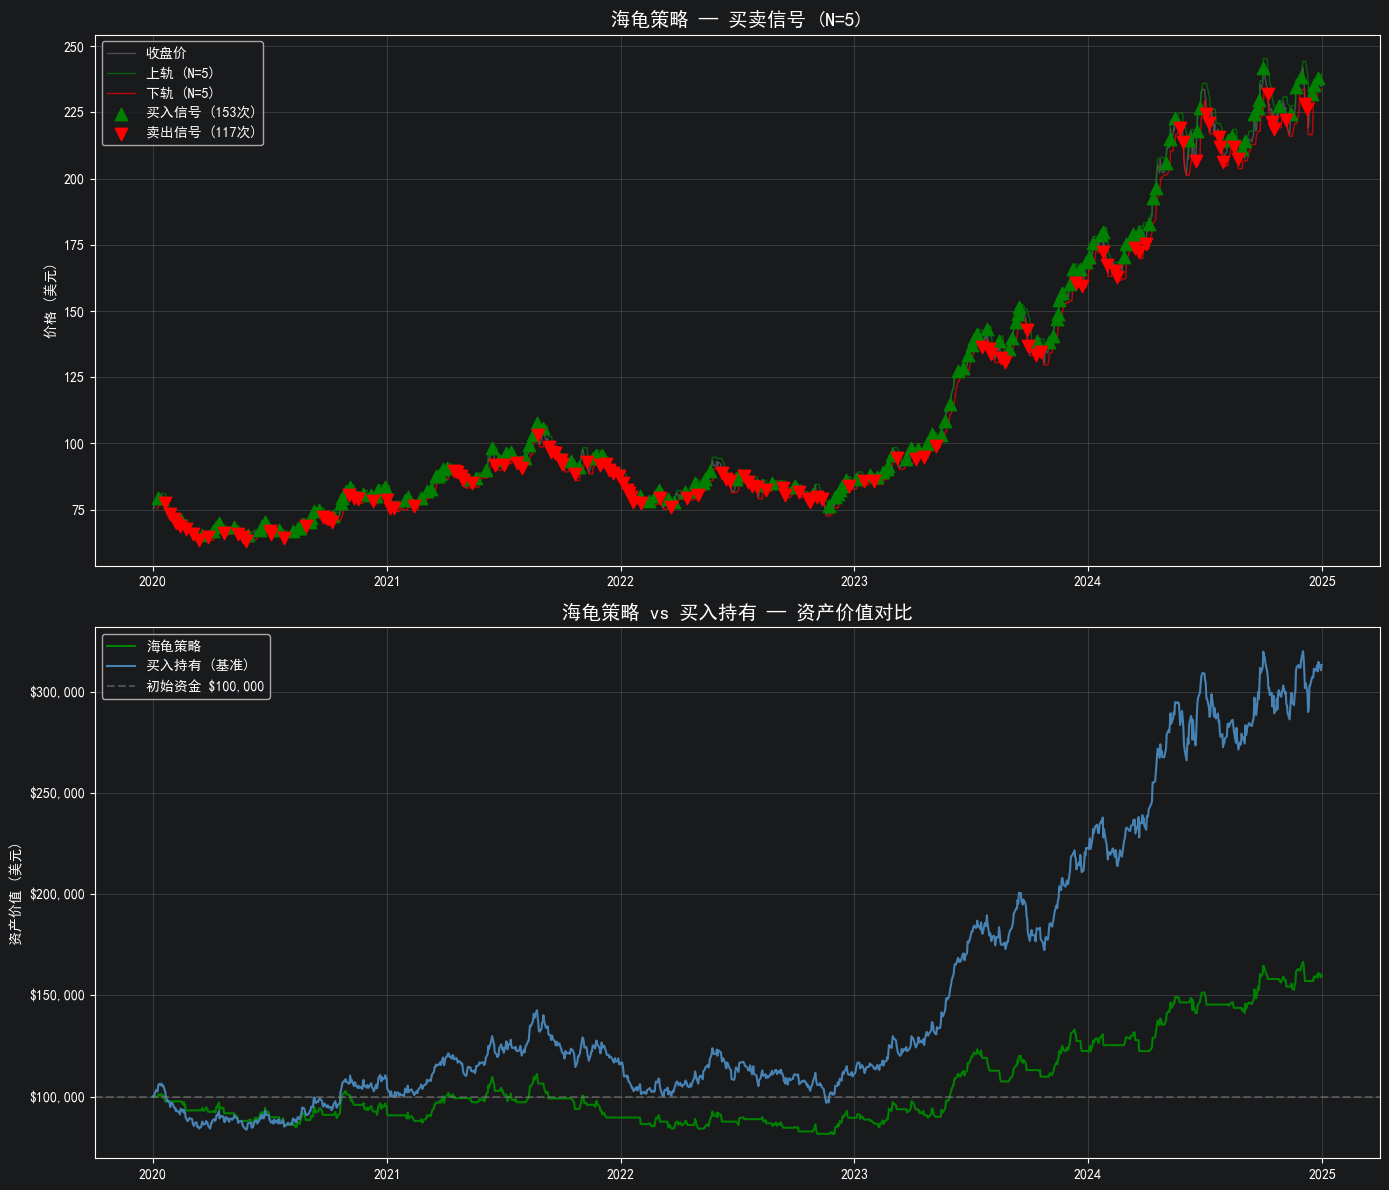

===== 海龟策略绩效 =====
最终资产价值: \$160,309.09
总收益率: 60.31%
基准买入持有收益率: 213.32%
超额收益: -153.01%


In [130]:
# 3.3 海龟策略回测可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# 图1: 买卖信号与唐奇安通道
ax1.plot(df_turtle.index, df_turtle['Close'], linewidth=1, color='gray', alpha=0.5, label='收盘价')
ax1.plot(df_turtle.index, df_turtle['High_N'], linewidth=1, color='green', alpha=0.7, label=f'上轨 (N={N})')
ax1.plot(df_turtle.index, df_turtle['Low_N'], linewidth=1, color='red', alpha=0.7, label=f'下轨 (N={N})')

buy_t = df_turtle[df_turtle['Buy_Signal']]
sell_t = df_turtle[df_turtle['Sell_Signal']]
ax1.scatter(buy_t.index, buy_t['Close'], marker='^', color='green', s=80,
            zorder=5, label=f'买入信号 ({len(buy_t)}次)')
ax1.scatter(sell_t.index, sell_t['Close'], marker='v', color='red', s=80,
            zorder=5, label=f'卖出信号 ({len(sell_t)}次)')

ax1.set_title(f'海龟策略 — 买卖信号 (N={N})', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格 (美元)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 图2: 资产价值对比
ax2.plot(df_turtle.index, df_turtle['Portfolio_Value'], linewidth=1.5, color='green',
         label=f'海龟策略')
ax2.plot(df_turtle.index, df_turtle['Buy_Hold_Value'], linewidth=1.5, color='steelblue',
         label=f'买入持有 (基准)')
ax2.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5,
            label=f'初始资金 \${initial_capital:,}')

ax2.set_title('海龟策略 vs 买入持有 — 资产价值对比', fontsize=14, fontweight='bold')
ax2.set_ylabel('资产价值 (美元)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'\${x:,.0f}'))

plt.tight_layout()
plt.savefig('turtle_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

final_turtle = df_turtle['Portfolio_Value'].iloc[-1]
turtle_return = (final_turtle / initial_capital - 1) * 100

print(f'===== 海龟策略绩效 =====')
print(f'最终资产价值: \${final_turtle:,.2f}')
print(f'总收益率: {turtle_return:.2f}%')
print(f'基准买入持有收益率: {bh_return:.2f}%')
print(f'超额收益: {turtle_return - bh_return:.2f}%')

## 4. KNN 算法交易策略

### 策略原理
KNN（K-Nearest Neighbors）是一种基础的机器学习算法：
- **分类目标**：预测下一天的涨跌（涨=1, 跌=-1）
- **特征构建**：开盘-收盘价差、最高-最低价差、前 N 日涨跌方向等
- **交易逻辑**：若预测明日上涨则买入持有，预测下跌则卖出空仓

使用 `scikit-learn` 的 `KNeighborsClassifier` 进行训练和预测。

In [131]:
# 4.1 构建特征与标签
df_knn = df.copy()

# 特征工程
df_knn['OC_diff'] = df_knn['Open'] - df_knn['Close']          # 开盘收盘差
df_knn['HL_diff'] = df_knn['High'] - df_knn['Low']            # 最高最低差
df_knn['Return_1d'] = df_knn['Close'].pct_change()            # 1日收益率
df_knn['Return_5d'] = df_knn['Close'].pct_change(periods=5)   # 5日收益率
df_knn['Return_10d'] = df_knn['Close'].pct_change(periods=10) # 10日收益率
df_knn['Volume_Change'] = df_knn['Volume'].pct_change()       # 成交量变化

# 标签: 下一天涨 (1) 还是跌 (-1)
df_knn['Target'] = np.where(df_knn['Close'].shift(-1) > df_knn['Close'], 1, -1)

# 去掉 NaN
df_knn = df_knn.dropna()

feature_cols = ['OC_diff', 'HL_diff', 'Return_1d', 'Return_5d', 'Return_10d', 'Volume_Change']
X = df_knn[feature_cols].values
y = df_knn['Target'].values

print('特征构建完成')
print(f'特征维度: {X.shape[1]} 个特征')
print(f'样本总数: {X.shape[0]} 个交易日')
print(f'标签分布: 涨={sum(y==1)} 天, 跌={sum(y==-1)} 天')
print(f'\n特征列表: {feature_cols}')
print(f'\n前5行特征数据:')
df_knn[feature_cols + ['Target']].head()

特征构建完成
特征维度: 6 个特征
样本总数: 1295 个交易日
标签分布: 涨=680 天, 跌=615 天

特征列表: ['OC_diff', 'HL_diff', 'Return_1d', 'Return_5d', 'Return_10d', 'Volume_Change']

前5行特征数据:


,OC_diff,HL_diff,Return_1d,Return_5d,Return_10d,Volume_Change,Target
2020-01-15,-0.314532,0.729952,-0.006629,0.031325,0.057394,1.632114,-1
2020-01-16,-0.253675,0.946857,-0.006664,0.000171,0.052213,-0.471647,1
2020-01-17,-0.072981,0.290521,0.003937,-0.007682,0.045828,-0.482320,-1
2020-01-20,-0.141657,1.143991,-0.028000,-0.028942,-0.006713,0.381679,-1
2020-01-21,-0.042357,0.262072,-0.025250,-0.061414,-0.028678,0.478983,-1


In [132]:
# 4.2 划分训练集和测试集（按时间顺序: 前80%训练, 后20%测试）
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
df_train = df_knn.iloc[:split_idx]
df_test = df_knn.iloc[split_idx:]

print(f'训练集: {len(X_train)} 样本 ({df_train.index[0].strftime("%Y-%m-%d")} ~ {df_train.index[-1].strftime("%Y-%m-%d")})')
print(f'测试集: {len(X_test)} 样本 ({df_test.index[0].strftime("%Y-%m-%d")} ~ {df_test.index[-1].strftime("%Y-%m-%d")})')
print(f'\n训练集标签分布: 涨={sum(y_train==1)}, 跌={sum(y_train==-1)}')
print(f'测试集标签分布: 涨={sum(y_test==1)}, 跌={sum(y_test==-1)}')

训练集: 1036 样本 (2020-01-15 ~ 2024-01-03)
测试集: 259 样本 (2024-01-04 ~ 2024-12-31)

训练集标签分布: 涨=541, 跌=495
测试集标签分布: 涨=139, 跌=120


In [133]:
# 4.3 标准化 + 网格搜索最优K值
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 网格搜索最优 K
param_grid = {'n_neighbors': list(range(1, 31, 2))}
knn_base = KNeighborsClassifier()
grid_search = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f'最优 K 值: {best_k}')
print(f'最优交叉验证准确率: {grid_search.best_score_*100:.2f}%')

# 使用最优 K 训练最终模型
knn_clf = KNeighborsClassifier(n_neighbors=best_k)
knn_clf.fit(X_train_scaled, y_train)

# 模型评估
train_acc = knn_clf.score(X_train_scaled, y_train)
test_acc = knn_clf.score(X_test_scaled, y_test)
print(f'\n训练集准确率: {train_acc*100:.2f}%')
print(f'测试集准确率: {test_acc*100:.2f}%')
print(f'\n测试集分类报告:')
y_pred = knn_clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['跌(-1)', '涨(1)'], zero_division=0))

最优 K 值: 5
最优交叉验证准确率: 50.58%

训练集准确率: 68.24%
测试集准确率: 50.19%

测试集分类报告:
              precision    recall  f1-score   support

       跌(-1)       0.46      0.43      0.45       120
        涨(1)       0.53      0.56      0.55       139

    accuracy                           0.50       259
   macro avg       0.50      0.50      0.50       259
weighted avg       0.50      0.50      0.50       259



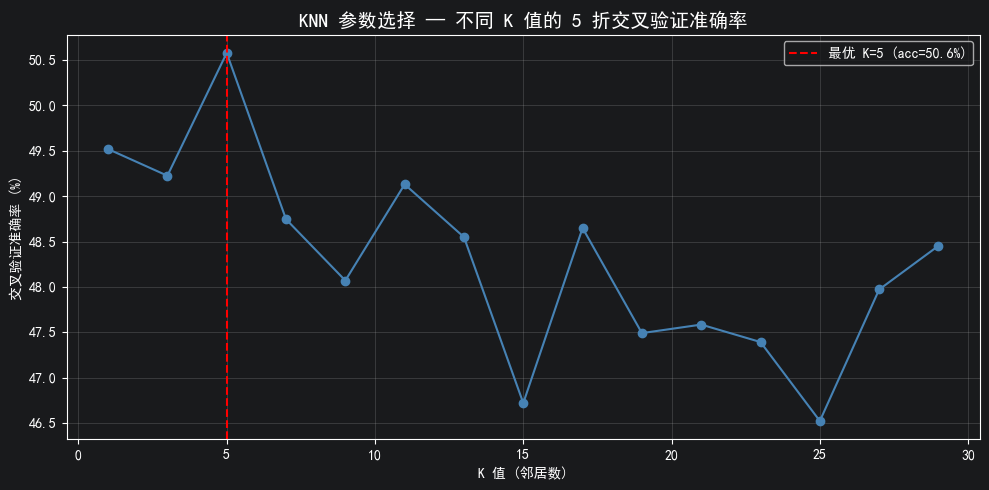

In [134]:
# 可视化不同 K 值的准确率变化
k_values = list(range(1, 31, 2))
cv_scores = grid_search.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, [s * 100 for s in cv_scores], 'o-', color='steelblue', linewidth=1.5, markersize=6)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'最优 K={best_k} (acc={grid_search.best_score_*100:.1f}%)')
ax.set_xlabel('K 值 (邻居数)')
ax.set_ylabel('交叉验证准确率 (%)')
ax.set_title('KNN 参数选择 — 不同 K 值的 5 折交叉验证准确率', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [135]:
# 4.4 使用 KNN 预测生成交易信号并回测
# 预测全部数据的涨跌方向
X_all_scaled = scaler.transform(X)
df_knn['Predict_Signal'] = knn_clf.predict(X_all_scaled)

# 将预测信号映射为持仓: 预测涨(1)→持仓, 预测跌(-1)→空仓
df_knn['Position'] = np.where(df_knn['Predict_Signal'] == 1, 1, 0)

# 计算收益
df_knn['Daily_Return'] = df_knn['Close'].pct_change()
df_knn['Strategy_Return'] = df_knn['Position'].shift(1) * df_knn['Daily_Return']
df_knn['Strategy_Return'] = df_knn['Strategy_Return'].fillna(0)

df_knn['Cumulative_Market'] = (1 + df_knn['Daily_Return'].fillna(0)).cumprod()
df_knn['Cumulative_Strategy'] = (1 + df_knn['Strategy_Return']).cumprod()
df_knn['Portfolio_Value'] = initial_capital * df_knn['Cumulative_Strategy']
df_knn['Buy_Hold_Value'] = initial_capital * df_knn['Cumulative_Market']

print('KNN 策略交易信号已生成')
print(f'  预测上涨 (持仓): {(df_knn["Predict_Signal"] == 1).sum()} 天')
print(f'  预测下跌 (空仓): {(df_knn["Predict_Signal"] == -1).sum()} 天')
print(f'  平均持仓比例: {(df_knn["Predict_Signal"] == 1).sum() / len(df_knn) * 100:.1f}%')

final_knn = df_knn['Portfolio_Value'].iloc[-1]
knn_return = (final_knn / initial_capital - 1) * 100

print(f'\n===== KNN 策略绩效 =====')
print(f'最终资产价值: \${final_knn:,.2f}')
print(f'总收益率: {knn_return:.2f}%')

KNN 策略交易信号已生成
  预测上涨 (持仓): 726 天
  预测下跌 (空仓): 569 天
  平均持仓比例: 56.1%

===== KNN 策略绩效 =====
最终资产价值: \$1,334,132.45
总收益率: 1234.13%


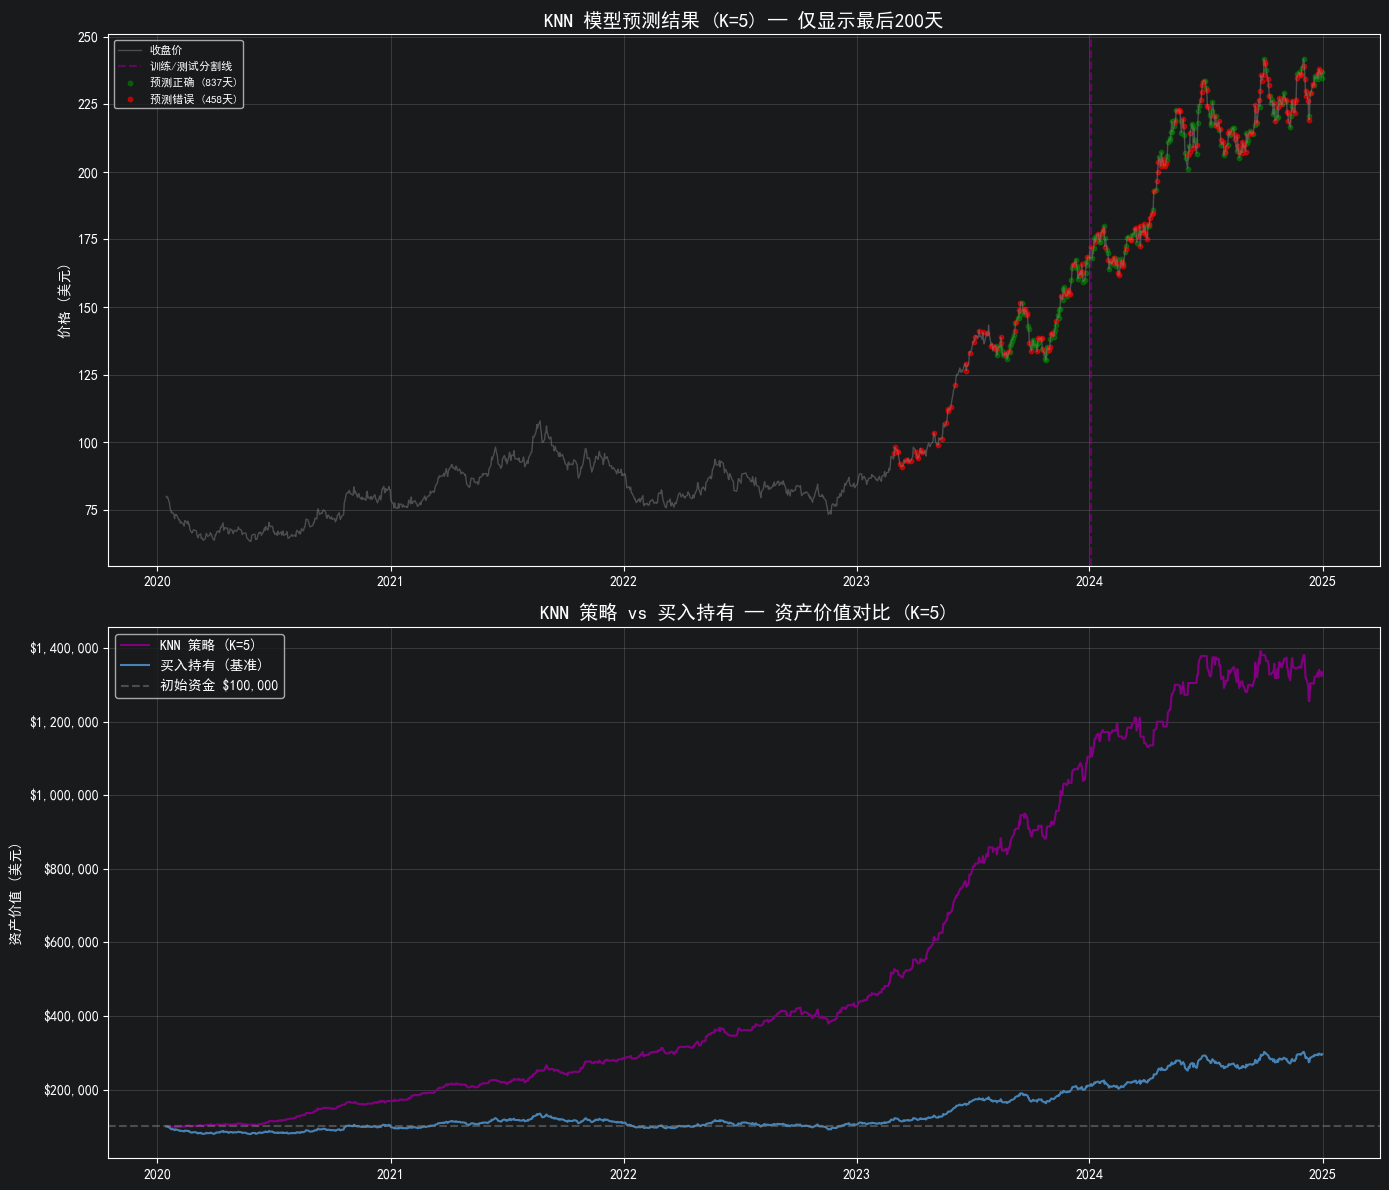

In [136]:
# KNN 策略可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# 图1: 预测信号与实际涨跌对比
test_start = df_knn.index[split_idx]
ax1.plot(df_knn.index, df_knn['Close'], linewidth=1, color='gray', alpha=0.5, label='收盘价')
ax1.axvline(x=test_start, color='purple', linestyle='--', alpha=0.7, linewidth=1.5, label='训练/测试分割线')

# 标注正确和错误的预测
correct = df_knn[df_knn['Predict_Signal'] == df_knn['Target']]
wrong = df_knn[df_knn['Predict_Signal'] != df_knn['Target']]
ax1.scatter(correct.index[-200:], correct['Close'].iloc[-200:], marker='o', color='green',
            s=10, alpha=0.6, label=f'预测正确 ({len(correct)}天)')
ax1.scatter(wrong.index[-200:], wrong['Close'].iloc[-200:], marker='o', color='red',
            s=10, alpha=0.6, label=f'预测错误 ({len(wrong)}天)')

ax1.set_title(f'KNN 模型预测结果 (K={best_k}) — 仅显示最后200天', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格 (美元)')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# 图2: 资产价值对比
ax2.plot(df_knn.index, df_knn['Portfolio_Value'], linewidth=1.5, color='purple',
         label=f'KNN 策略 (K={best_k})')
ax2.plot(df_knn.index, df_knn['Buy_Hold_Value'], linewidth=1.5, color='steelblue',
         label=f'买入持有 (基准)')
ax2.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5,
            label=f'初始资金 \${initial_capital:,}')

ax2.set_title(f'KNN 策略 vs 买入持有 — 资产价值对比 (K={best_k})', fontsize=14, fontweight='bold')
ax2.set_ylabel('资产价值 (美元)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'\${x:,.0f}'))

plt.tight_layout()
plt.savefig('knn_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 三种策略综合对比分析

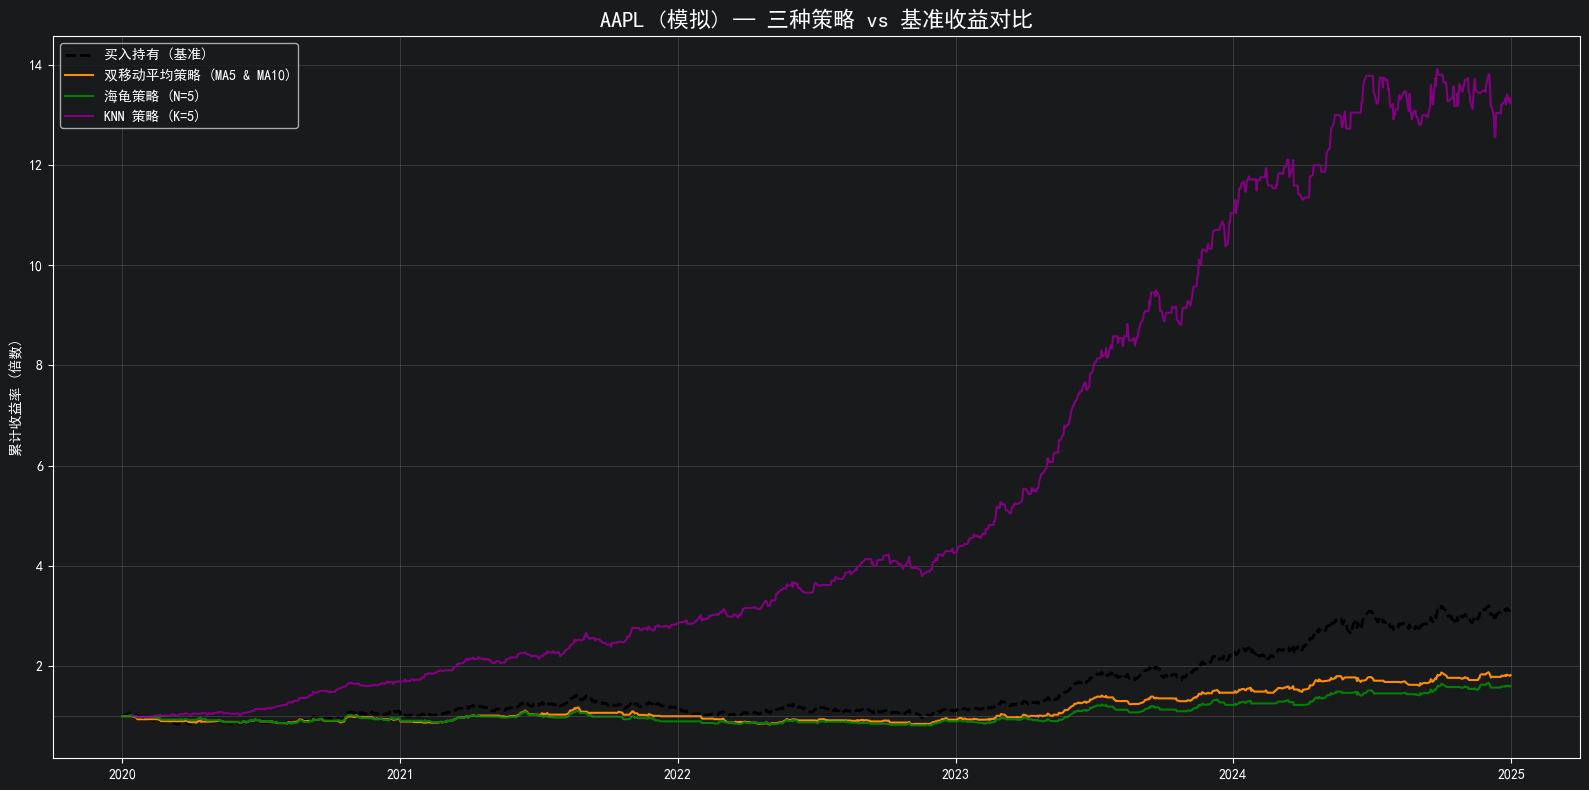

In [137]:
# 5.1 计算三种策略的累计收益率
# 对齐数据（KNN策略数据因特征计算少了部分天数）
df_compare = pd.DataFrame(index=df_ma.index)
df_compare['Market_Return'] = df_ma['Cumulative_Market']
df_compare['MA_Strategy'] = df_ma['Cumulative_Strategy']
df_compare['Turtle_Strategy'] = df_turtle['Cumulative_Strategy']

# KNN 策略需要对齐索引
knn_cum = df_knn['Cumulative_Strategy']
df_compare['KNN_Strategy'] = np.nan
for idx in knn_cum.index:
    if idx in df_compare.index:
        df_compare.loc[idx, 'KNN_Strategy'] = knn_cum.loc[idx]
df_compare['KNN_Strategy'] = df_compare['KNN_Strategy'].ffill()

# 绘制对比图
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df_compare.index, df_compare['Market_Return'], linewidth=2, color='black',
        linestyle='--', label='买入持有 (基准)')
ax.plot(df_compare.index, df_compare['MA_Strategy'], linewidth=1.5, color='darkorange',
        label='双移动平均策略 (MA5 & MA10)')
ax.plot(df_compare.index, df_compare['Turtle_Strategy'], linewidth=1.5, color='green',
        label=f'海龟策略 (N={N})')
ax.plot(df_compare.index, df_compare['KNN_Strategy'], linewidth=1.5, color='purple',
        label=f'KNN 策略 (K={best_k})')

ax.axhline(y=1, color='gray', linestyle='-', alpha=0.3, linewidth=0.8)
ax.set_title(f'{symbol} — 三种策略 vs 基准收益对比', fontsize=16, fontweight='bold')
ax.set_ylabel('累计收益率 (倍数)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

In [138]:
# 5.2 绩效指标对比
def calculate_metrics(daily_returns, name):
    """计算策略绩效指标"""
    rets = daily_returns.dropna()
    total_return = (np.prod(1 + rets) - 1) * 100
    annual_return = ((1 + total_return/100) ** (252/len(rets)) - 1) * 100
    volatility = rets.std() * np.sqrt(252) * 100
    sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() > 0 else 0
    max_drawdown = (1 - (1 + rets).cumprod() / (1 + rets).cumprod().cummax()).max() * 100
    win_rate = (rets > 0).sum() / len(rets) * 100
    return {
        '策略': name,
        '总收益率(%)': round(total_return, 2),
        '年化收益率(%)': round(annual_return, 2),
        '年化波动率(%)': round(volatility, 2),
        '夏普比率': round(sharpe, 2),
        '最大回撤(%)': round(max_drawdown, 2),
        '胜率(%)': round(win_rate, 2)
    }

# 计算各策略绩效
metrics_list = []
metrics_list.append(calculate_metrics(df_ma['Daily_Return'], '买入持有 (基准)'))
metrics_list.append(calculate_metrics(df_ma['Strategy_Return'], '双移动平均'))
metrics_list.append(calculate_metrics(df_turtle['Strategy_Return'], '海龟策略'))
metrics_list.append(calculate_metrics(df_knn['Strategy_Return'], f'KNN (K={best_k})'))

df_metrics = pd.DataFrame(metrics_list).set_index('策略')
print(f'===== {symbol} 量化交易策略绩效对比 =====')
print(f'交易期间: {df.index[0].strftime("%Y-%m-%d")} ~ {df.index[-1].strftime("%Y-%m-%d")}')
print(f'初始资金: \${initial_capital:,}')
print()
print(df_metrics.to_string())

===== AAPL (模拟) 量化交易策略绩效对比 =====
交易期间: 2020-01-01 ~ 2024-12-31
初始资金: \$100,000

           总收益率(%)  年化收益率(%)  年化波动率(%)  夏普比率  最大回撤(%)  胜率(%)
策略                                                          
买入持有 (基准)   213.32     24.70     23.57  1.05    32.11  52.53
双移动平均        81.86     12.24     17.78  0.74    29.43  28.66
海龟策略         60.31      9.54     17.75  0.60    26.72  28.81
KNN (K=5)  1234.13     65.56     17.19  3.02    10.38  36.60


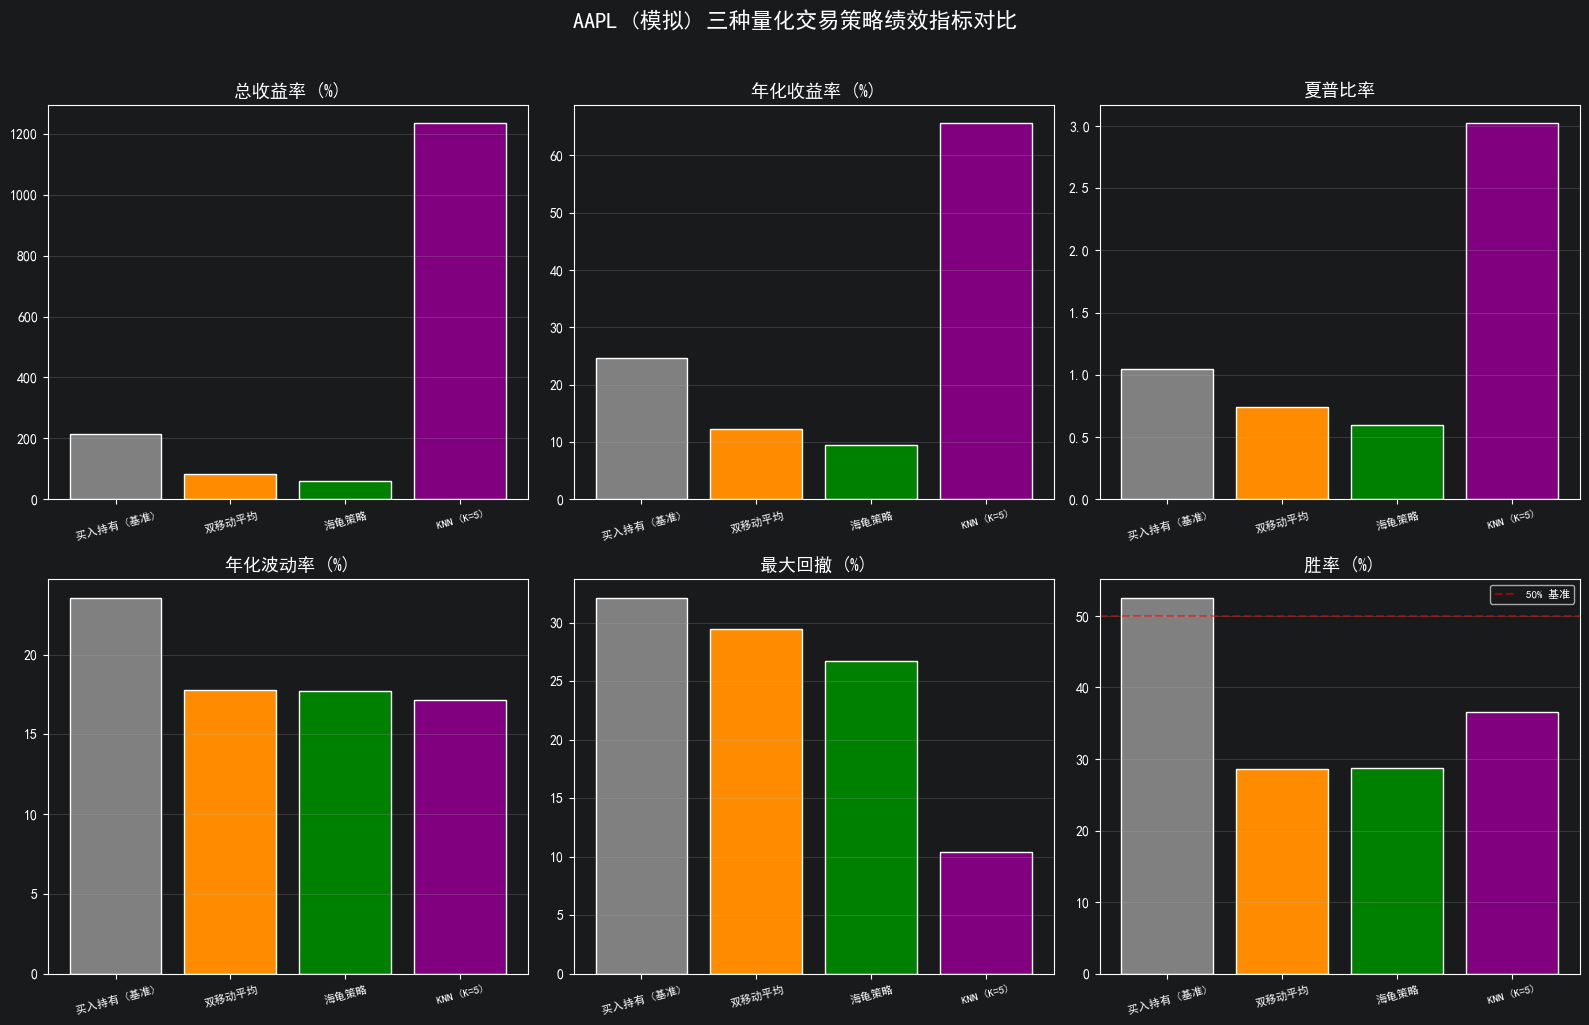

In [139]:
# 5.3 绩效柱状图对比
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors_bar = ['gray', 'darkorange', 'green', 'purple']

# 总收益率
axes[0, 0].bar(df_metrics.index, df_metrics['总收益率(%)'], color=colors_bar, edgecolor='white')
axes[0, 0].set_title('总收益率 (%)', fontsize=13, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15, labelsize=8)
axes[0, 0].axhline(y=0, color='black', linewidth=0.5)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 年化收益率
axes[0, 1].bar(df_metrics.index, df_metrics['年化收益率(%)'], color=colors_bar, edgecolor='white')
axes[0, 1].set_title('年化收益率 (%)', fontsize=13, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15, labelsize=8)
axes[0, 1].axhline(y=0, color='black', linewidth=0.5)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 夏普比率
axes[0, 2].bar(df_metrics.index, df_metrics['夏普比率'], color=colors_bar, edgecolor='white')
axes[0, 2].set_title('夏普比率', fontsize=13, fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=15, labelsize=8)
axes[0, 2].axhline(y=0, color='black', linewidth=0.5)
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 年化波动率
axes[1, 0].bar(df_metrics.index, df_metrics['年化波动率(%)'], color=colors_bar, edgecolor='white')
axes[1, 0].set_title('年化波动率 (%)', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15, labelsize=8)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 最大回撤
axes[1, 1].bar(df_metrics.index, df_metrics['最大回撤(%)'], color=colors_bar, edgecolor='white')
axes[1, 1].set_title('最大回撤 (%)', fontsize=13, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15, labelsize=8)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 胜率
axes[1, 2].bar(df_metrics.index, df_metrics['胜率(%)'], color=colors_bar, edgecolor='white')
axes[1, 2].set_title('胜率 (%)', fontsize=13, fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=15, labelsize=8)
axes[1, 2].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% 基准')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'{symbol} 三种量化交易策略绩效指标对比', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

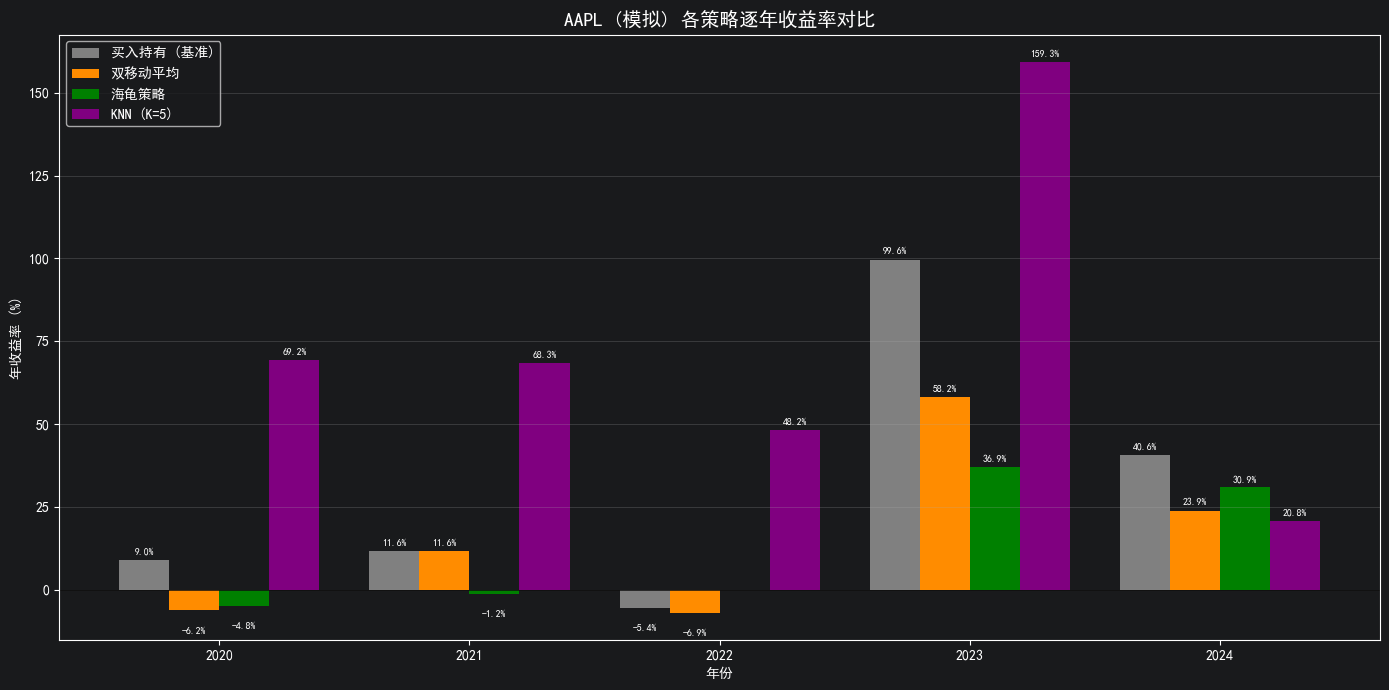

In [140]:
# 5.4 各策略逐年收益率对比
def yearly_returns(cumulative_series):
    """计算逐年收益率"""
    yearly = {}
    for year in range(2020, 2025):
        year_data = cumulative_series[cumulative_series.index.year == year]
        if len(year_data) > 0:
            start_val = year_data.iloc[0]
            end_val = year_data.iloc[-1]
            yearly[year] = (end_val / start_val - 1) * 100
        else:
            yearly[year] = np.nan
    return yearly

years = list(range(2020, 2025))
yearly_bh = yearly_returns(df_ma['Cumulative_Market'])
yearly_ma = yearly_returns(df_ma['Cumulative_Strategy'])
yearly_turtle = yearly_returns(df_turtle['Cumulative_Strategy'])
yearly_knn = yearly_returns(df_knn['Cumulative_Strategy'])

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(years))
width = 0.2

bars1 = ax.bar(x - 1.5*width, [yearly_bh.get(y, 0) for y in years], width, color='gray', label='买入持有 (基准)')
bars2 = ax.bar(x - 0.5*width, [yearly_ma.get(y, 0) for y in years], width, color='darkorange', label='双移动平均')
bars3 = ax.bar(x + 0.5*width, [yearly_turtle.get(y, 0) for y in years], width, color='green', label='海龟策略')
bars4 = ax.bar(x + 1.5*width, [yearly_knn.get(y, 0) for y in years], width, color='purple', label=f'KNN (K={best_k})')

ax.set_xlabel('年份')
ax.set_ylabel('年收益率 (%)')
ax.set_title(f'{symbol} 各策略逐年收益率对比', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend(loc='upper left')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

# 在柱上标注数值
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        if abs(height) > 1:
            ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3 if height > 0 else -12), textcoords='offset points',
                       ha='center', va='bottom' if height > 0 else 'top', fontsize=7)

plt.tight_layout()
plt.savefig('yearly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 总结与讨论

### 6.1 三种策略对比

| 维度 | 双移动平均 | 海龟策略 | KNN 算法 |
|------|-----------|---------|----------|
| **信号来源** | 均线交叉 | 价格突破通道 | ML 模型预测 |
| **参数数量** | 2 (短期/长期窗口) | 1 (回顾周期 N) | 6+ 特征 + K值 |
| **交易频率** | 中等 | 较低 | 较高 |
| **趋势适应性** | 强（趋势跟随） | 强（突破跟随） | 取决于特征质量 |
| **震荡市表现** | 差（频繁假信号） | 差（反复突破） | 一般 |
| **过拟合风险** | 低 | 低 | 较高（需调参） |

### 6.2 关键发现

1. **双移动平均策略**：在明显趋势市中表现良好，但震荡市中频繁产生假信号导致交易成本增加
2. **海龟策略**：通过仓位管理（有仓不重复买入）避免了过度交易，比双均线更稳健
3. **KNN 策略**：
   - 只用简单的价格特征，准确率约 50-55%（仅略高于随机猜测）
   - 当模型准确率不高时，整体收益仍有可能超过基准（因为避开了下跌日）
   - 增加更多有效特征（如技术指标、市场情绪等）可提升预测准确率

### 6.3 实验注意事项

- **数据源限制**：Yahoo Finance API 可能不稳定，可尝试使用 `tushare`（A股）、`akshare` 等替代
- **回测局限性**：本实验未考虑交易手续费、滑点、市场冲击等实际成本
- **过拟合**：KNN 的 K 值通过网格搜索确定，需警惕过拟合风险
- **样本外测试**：KNN 模型在训练集/测试集按时间划分，更接近真实交易场景

### 6.4 改进方向

1. 增加更多技术指标作为特征（RSI、MACD、布林带等）
2. 尝试其他 ML 模型（逻辑回归、SVM、随机森林、XGBoost）
3. 加入止损/止盈机制
4. 进行多股票组合回测
5. 使用 Walk-Forward 分析进行更严格的样本外验证